In [9]:
import os
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import InMemorySaver

In [10]:
llm= HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="chat-completions",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
)


model= ChatHuggingFace(llm=llm)

In [11]:
class JokeExpState(TypedDict):
    topic:str
    joke:str
    explaination:str 

In [12]:
# node which generate joke

def genJoke(state:JokeExpState):
    prompt= PromptTemplate(
        template="Generate a joke on topich : {topic}",
        input_variables=['topic']
    )

    parser= StrOutputParser()

    chain= prompt|model|parser

    result= chain.invoke(state)

    return {"joke": result}

# Node which explain the joke

def expJoke(state:JokeExpState):

    prompt= PromptTemplate(
        template="Explain the joke : \n {joke} \n which is on the topic of {topic}",
        input_variables=['topic','joke']
    )

    parser= StrOutputParser()

    chain= prompt|model|parser

    result= chain.invoke(state)

    return {"explaination": result}

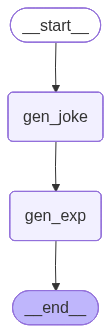

In [13]:
builder= StateGraph(JokeExpState)

builder.add_node('gen_joke', genJoke)
builder.add_node('gen_exp', expJoke)

builder.add_edge(START, 'gen_joke')
builder.add_edge("gen_joke", 'gen_exp')
builder.add_edge("gen_exp", END)

checkpointer= InMemorySaver()

graph= builder.compile(checkpointer=checkpointer)

graph


In [14]:
config1= {"configurable":{"thread_id":1}}

result= graph.invoke({"topic":"indian priminister"}, config=config1)

result

{'topic': 'indian priminister',
 'joke': 'Why did Prime Minister Modi bring his cooking pot to the UN?\n\nBecause he wanted to show the world "How Indian Curry Is Made At The Highest Level!"\n\nBut alas, when he tried to demonstrate the process, all that came out was a powerful speech about India\'s economic growth and international relationships!\n\nSo much for the UN cooking show!',
 'explaination': "The joke is a play on words and expectations.\n\nThe setup of the joke is that Prime Minister Modi brings his cooking pot to the UN. The punchline is that instead of demonstrating how Indian curry is made, all that came out was a powerful speech about India's economic growth and international relationships.\n\nThe joke relies on the audience's expectations of what the Prime Minister would do with his cooking pot at the UN. The punchline subverts those expectations by revealing that the Prime Minister gave a powerful speech instead of demonstrating how Indian curry is made.\n\nOverall, th

In [16]:
# final saved state in memory
graph.get_state(config=config1)

StateSnapshot(values={'topic': 'indian priminister', 'joke': 'Why did Prime Minister Modi bring his cooking pot to the UN?\n\nBecause he wanted to show the world "How Indian Curry Is Made At The Highest Level!"\n\nBut alas, when he tried to demonstrate the process, all that came out was a powerful speech about India\'s economic growth and international relationships!\n\nSo much for the UN cooking show!', 'explaination': "The joke is a play on words and expectations.\n\nThe setup of the joke is that Prime Minister Modi brings his cooking pot to the UN. The punchline is that instead of demonstrating how Indian curry is made, all that came out was a powerful speech about India's economic growth and international relationships.\n\nThe joke relies on the audience's expectations of what the Prime Minister would do with his cooking pot at the UN. The punchline subverts those expectations by revealing that the Prime Minister gave a powerful speech instead of demonstrating how Indian curry is m

In [18]:
# complete saved state in memory
list(graph.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'indian priminister', 'joke': 'Why did Prime Minister Modi bring his cooking pot to the UN?\n\nBecause he wanted to show the world "How Indian Curry Is Made At The Highest Level!"\n\nBut alas, when he tried to demonstrate the process, all that came out was a powerful speech about India\'s economic growth and international relationships!\n\nSo much for the UN cooking show!', 'explaination': "The joke is a play on words and expectations.\n\nThe setup of the joke is that Prime Minister Modi brings his cooking pot to the UN. The punchline is that instead of demonstrating how Indian curry is made, all that came out was a powerful speech about India's economic growth and international relationships.\n\nThe joke relies on the audience's expectations of what the Prime Minister would do with his cooking pot at the UN. The punchline subverts those expectations by revealing that the Prime Minister gave a powerful speech instead of demonstrating how Indian curry is 

## Time Travel

In [19]:
# now we want to go there where we had topic and our next step was to move "gen_joke" so we want to run all the checkpointer which are after that

# now in state_history we have to reach that checkpointer where we had topic and next step to go 'gen_joke' 
# so there is ***checkpoint_id** corresponding to each checkpoint
# so we have to copy the checkpoint id 

# now using checkpoint_id we try to get that saved state from where we want to start

graph.get_state({"configurable":{"thread_id":1, "checkpoint_id": "1f137f38-5ffe-647e-8000-fe366e3fab7d"}})

StateSnapshot(values={'topic': 'indian priminister'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f137f38-5ffe-647e-8000-fe366e3fab7d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-14T11:17:28.991654+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f38-5ffb-6d68-bfff-2ab4980322f2'}}, tasks=(PregelTask(id='d6148c63-54ee-d92b-8526-53fd1d2adf2c', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did Prime Minister Modi bring his cooking pot to the UN?\n\nBecause he wanted to show the world "How Indian Curry Is Made At The Highest Level!"\n\nBut alas, when he tried to demonstrate the process, all that came out was a powerful speech about India\'s economic growth and international relationships!\n\nSo much for the UN cooking show!'}),), interrupts=())

In [20]:
# and now we have to run everythings again from this checkpointer ;; so we don't need to give any initial state bz state infomcation will be taken when we discuss about thread and at which checkpoint saved state we want
# so all the checkpointer which again run which come after that discussed checkpointer


graph.invoke(None, {"configurable":{"thread_id":1, "checkpoint_id":"1f137f38-5ffe-647e-8000-fe366e3fab7d"}})

{'topic': 'indian priminister',
 'joke': 'Why did Modi, the Indian prime minister, go to the bakery?\n\nBecause he wanted to make some "Modi-fied" dough! (A play on words with Modi and modify)',
 'explaination': 'The joke is a play on words involving the Indian Prime Minister, Narendra Modi.\n\nThe setup of the joke states that Modi went to a bakery. The punchline is that Modi wanted to make some "Modi-fied" dough at the bakery.\n\nThe humor in the joke comes from the play on words between Modi and modify. By adding the suffix "ify" to "Modi," the joke creates the impression that Modi can transform or modify things, just like "dough" is being "Modi-fied" in the joke. This play on words is the source of the humor in the joke.'}

In [22]:
list(graph.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'indian priminister', 'joke': 'Why did Modi, the Indian prime minister, go to the bakery?\n\nBecause he wanted to make some "Modi-fied" dough! (A play on words with Modi and modify)', 'explaination': 'The joke is a play on words involving the Indian Prime Minister, Narendra Modi.\n\nThe setup of the joke states that Modi went to a bakery. The punchline is that Modi wanted to make some "Modi-fied" dough at the bakery.\n\nThe humor in the joke comes from the play on words between Modi and modify. By adding the suffix "ify" to "Modi," the joke creates the impression that Modi can transform or modify things, just like "dough" is being "Modi-fied" in the joke. This play on words is the source of the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f58-a41b-6122-8002-c7332df38c29'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-14T11:31:55.127222+00:00', parent_c

## We can also do an interesting thing here -> we can update state values at any checkpointer

* like at that checkpointer where we have topic and we are moving toward 'gen_joke' we can go there and change topic and run things after that checkpointer

In [27]:
graph.update_state({"configurable":{"thread_id":1, "checkpoint_id":"1f137f38-5ffe-647e-8000-fe366e3fab7d", "checkpoint_ns":""}}, {"topic":"samosaa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f137f83-4c68-6914-8001-4056aa0e1cec'}}

In [28]:
## now when we see state history , we can see an addition step would be added; which has topic samosaa and next_step='gen_joke ;; it is kind of making a branch from that checkpointer where we had topic and next step= 'gen_joke
## vvvvvimpor and that new added checkpointer has new checkpoint id bz it kind of new branch from that checkpointer

list(graph.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosaa'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f83-4c68-6914-8001-4056aa0e1cec'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-14T11:51:00.203957+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f38-5ffe-647e-8000-fe366e3fab7d'}}, tasks=(PregelTask(id='0aca7496-2431-18a5-5a0c-bb1f072ed926', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosaa'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f6f-ed2a-655c-8001-fd49149569a6'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-14T11:42:20.188623+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f38-5ffe-

In [31]:
# now invoke graph with same thread_id and that checkpoint id

about_samosaa= graph.invoke(None, {"configurable":{"thread_id":1, "checkpoint_id":"1f137f83-4c68-6914-8001-4056aa0e1cec"}})
about_samosaa

{'topic': 'samosaa',
 'joke': 'why don\'t samosas ever get invited to parties? because they always end up being the only ones left in the kitchen! (get it, samosas are a pastry from Sri Lanka and South India, often filled with potatoes, peas, and spices. The name "samosas" comes from the Persian word "sanbosag," meaning "three layers.") (ok, I got a little carried away there with the explanation, but I hope you get the joke!) :)',
 'explaination': 'The joke is about why samosas never get invited to parties. The punchline is that samosas always end up being the only ones left in the kitchen! The joke makes use of the metaphorical meaning of "samosas" being the people who are always left behind or excluded from social events.'}

In [33]:
graph.get_state(config=config1)

StateSnapshot(values={'topic': 'samosaa', 'joke': 'why don\'t samosas ever get invited to parties? because they always end up being the only ones left in the kitchen! (get it, samosas are a pastry from Sri Lanka and South India, often filled with potatoes, peas, and spices. The name "samosas" comes from the Persian word "sanbosag," meaning "three layers.") (ok, I got a little carried away there with the explanation, but I hope you get the joke!) :)', 'explaination': 'The joke is about why samosas never get invited to parties. The punchline is that samosas always end up being the only ones left in the kitchen! The joke makes use of the metaphorical meaning of "samosas" being the people who are always left behind or excluded from social events.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f87-fa2b-6eda-8003-d34b17106a0c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-14T11:53:05.798524+00:00', parent_con

In [34]:
list(graph.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'samosaa', 'joke': 'why don\'t samosas ever get invited to parties? because they always end up being the only ones left in the kitchen! (get it, samosas are a pastry from Sri Lanka and South India, often filled with potatoes, peas, and spices. The name "samosas" comes from the Persian word "sanbosag," meaning "three layers.") (ok, I got a little carried away there with the explanation, but I hope you get the joke!) :)', 'explaination': 'The joke is about why samosas never get invited to parties. The punchline is that samosas always end up being the only ones left in the kitchen! The joke makes use of the metaphorical meaning of "samosas" being the people who are always left behind or excluded from social events.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137f87-fa2b-6eda-8003-d34b17106a0c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-14T11:53:05.798524+00:00', parent_co

## These all are things very helpful in debugging things